In [1]:
############################################
## Alles Importeren en Mappen Definiëren
############################################

import numpy as np
import pandas as pd
import scipy as sp
import  pickle
from scipy.fft import fft
from time import localtime, strftime
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from skimage.morphology import  disk,remove_small_objects
from skimage.filters.rank import gradient
from skimage.util import img_as_ubyte 
from skimage.feature import match_template
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, models
from tqdm import tqdm
import wave
import os
import librosa 


essential_folder = 'essential_data/'
spectro_folder = 'spectrograms2/'
dp_folder = 'DP/'
subm_folder = 'Submission/'
log_folder = 'log/'
model_folder = 'models/'


# Essential Data inladen

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fri, 31 Oct 2025 09:39:01 +0000
Using 16 CPU cores
Creating spectrograms...


Spectrograms: 100%|██████████| 645/645 [00:04<00:00, 130.28it/s]


Fri, 31 Oct 2025 09:39:06 +0000
Extracting segments in parallel...


Segments: 100%|██████████| 645/645 [01:51<00:00,  5.79it/s]


Fri, 31 Oct 2025 09:40:57 +0000


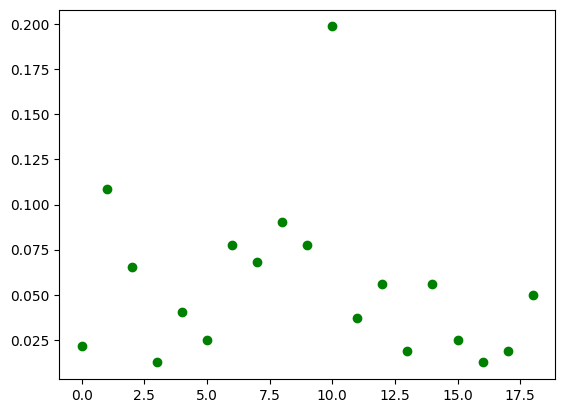

In [2]:
###################################################
## Read the Essential Data 
## labels, training-test split,file_names etc.
###################################################

# Each audio file has a unique recording identifier ("rec_id"), ranging from 0 to 644. 
# The file rec_id2filename.txt indicates which wav file is associated with each rec_id.
rec2f = pd.read_csv(essential_folder + 'rec_id2filename.txt', sep = ',')

# There are 19 bird species in the dataset. species_list.txt gives each a number from 0 to 18. 
species = pd.read_csv(essential_folder + 'species_list.txt', sep = ',')
num_species = 19

# The dataset is split into training and test sets. 
# CVfolds_2.txt gives the fold for each rec_id. 0 is the training set, and 1 is the test set.
cv =  pd.read_csv(essential_folder + 'CVfolds_2.txt', sep = ',')

# This is your main label training data. For each rec_id, a set of species is listed. The format is:
# rec_id,[labels]
raw =  pd.read_csv(essential_folder + 'rec_labels_test_hidden.txt', sep = ';')
label = np.zeros(len(raw)*num_species)
label = label.reshape([len(raw),num_species])
for i in range(len(raw)):
    line = raw.iloc[i]  # Use iloc[] instead of iloc()
    # Get the first column value and convert to string
    line_str = str(line.iloc[0]) if hasattr(line, 'iloc') else str(line[0])
    labels = line_str.split(',')
    labels.pop(0) # rec_id == i
    for c in labels:
        if(c != '?'):
            label[i,int(c)] = 1  # Convert c to int

label = pd.DataFrame(label)
label['rec_id'] = cv.rec_id
label['fold'] = cv.fold
label['filename'] = rec2f.filename

# Sparse training set 
# training species 1%--5%--20% 
spec_avg = label[label.fold ==0][range(num_species)].mean()
spec_avg.sort_values()
plt.plot(spec_avg,'go')

# Read the audio files 
# /src_wavs
# This folder contains the original wav files for the dataset (both training and test sets). 
# These are 10-second mono recordings sampled at 16kHz, 16 bits per sample.


def pic_to_ubyte (pic):
    a = (pic-np.min(pic) ) /(np.max(pic - np.min(pic))) 
    a = img_as_ubyte(a)
    return a


# Parameters to create the spectrogram
N = 160000
K = 512
Step = 4
wind =  0.5*(1 -np.cos(np.array(range(K))*2*np.pi/(K-1) ))
ffts = []


def wav_to_floats(filename):
    s = wave.open(filename,'r')
    strsig = s.readframes(s.getnframes())
    y = np.frombuffer(strsig, np.short)  # Changed from np.fromstring to np.frombuffer
    s.close()
    return y

 
###############################
## Create the Spectrograms
## Train + Test
###############################
from joblib import Parallel, delayed
import multiprocessing
from tqdm.auto import tqdm

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print(f"Using {multiprocessing.cpu_count()} CPU cores")

def process_single_file(file_idx):
    """Process a single audio file to create spectrogram"""
    test_flag = label.iloc[file_idx]['fold']
    fname = label.iloc[file_idx]['filename']
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):
            species_on_pic.append(n)
    
    S = wav_to_floats(essential_folder+'src_wavs/'+fname+'.wav')
    Spectogram = []
    for j in range(int(Step*N//K)-Step):  # Use integer division
        vec = S[j * K//Step : (j+Step) * K//Step] * wind
        Spectogram.append(abs(fft(vec,K)[:K//2]))
    
    return np.array(Spectogram)

# Parallel processing - uses all CPU cores with progress bar
print("Creating spectrograms...")
with tqdm(total=len(label), desc="Spectrograms") as pbar:
    ffts = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_single_file)(file_idx) for file_idx in range(len(label))
    ):
        ffts.append(result)
        pbar.update(1)

        
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
SPEC_SEGMENTS = []
LOG_SPEC_SEGMENTS = []
MIN_SEGMENT_SIZE = 99
p = 90

def process_segments_for_file(file_idx):
    """Extract segments from a single file"""
    test_flag = label.iloc[file_idx]['fold']
    fname = label.iloc[file_idx]['filename']
    species_on_pic = []
    for n in range(num_species):
        if(label.iloc[file_idx][n] > 0):
            species_on_pic.append(n)
    
    label_count = label.iloc[file_idx][range(num_species)].sum()
    bird_spec = label.iloc[file_idx][range(num_species)].argmax()
    
    file_spec_segments = []
    file_log_segments = []
    
    if(test_flag < 1 and label_count == 1):
        mypic = np.transpose(ffts[file_idx])
        mypic_rev = np.flipud(mypic)  # Faster than loop
        
        mypic_rev_small = mypic_rev[:200,:]
        mypic_rev = mypic_rev_small
        mypic_rev_log = np.log10(mypic_rev + 0.001)
        mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev, sigma=3)
        mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
        mypic_rev_gauss_bin = mypic_rev_gauss > np.percentile(mypic_rev_gauss, p)
        mypic_rev_log_gauss_bin = mypic_rev_log_gauss > np.percentile(mypic_rev_log_gauss, p)
        mypic_rev_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_bin))
        mypic_rev_log_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_bin))
        mypic_rev_gauss_grad = gradient(pic_to_ubyte(mypic_rev_gauss), disk(3))
        mypic_rev_log_gauss_grad = gradient(pic_to_ubyte(mypic_rev_log_gauss), disk(3))
        mypic_rev_gauss_grad_bin = mypic_rev_gauss_grad > np.percentile(mypic_rev_gauss_grad, p)
        mypic_rev_log_gauss_grad_bin = mypic_rev_log_gauss_grad > np.percentile(mypic_rev_log_gauss_grad, p)
        mypic_rev_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_grad_bin))
        mypic_rev_log_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_grad_bin))
        bfh = sp.ndimage.binary_fill_holes(mypic_rev_gauss_grad_bin_close)
        bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
        log_bfh = sp.ndimage.binary_fill_holes(mypic_rev_log_gauss_grad_bin_close)
        log_bfh_rm = remove_small_objects(log_bfh, MIN_SEGMENT_SIZE)
        
        # SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(bfh_rm)
        for current_segment_id in range(1, num_seg+1):
            current_segment = (labeled_segments == current_segment_id) * 1
            xr = current_segment.max(axis=0)
            yr = current_segment.max(axis=1)
            xr_max = np.max(xr * np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr * np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_gauss[yr_min:yr_max+1, xr_min:xr_max+1]
            file_spec_segments.append([file_idx, current_segment_id, segment_frame, subpic])
        
        # LOG SEGMENTS
        labeled_segments, num_seg = sp.ndimage.label(log_bfh_rm)
        for current_segment_id in range(1, num_seg+1):
            current_segment = (labeled_segments == current_segment_id) * 1
            xr = current_segment.max(axis=0)
            yr = current_segment.max(axis=1)
            xr_max = np.max(xr * np.arange(len(xr)))
            xr[xr==0] = xr.shape[0]
            xr_min = np.argmin(xr)
            yr_max = np.max(yr * np.arange(len(yr)))
            yr[yr==0] = yr.shape[0]
            yr_min = np.argmin(yr)
            segment_frame = [yr_min, yr_max, xr_min, xr_max]
            subpic = mypic_rev_log_gauss[yr_min:yr_max+1, xr_min:xr_max+1]
            file_log_segments.append([file_idx, current_segment_id, segment_frame, subpic])
    
    return file_spec_segments, file_log_segments

# Parallel segment extraction
print("Extracting segments in parallel...")
with tqdm(total=len(label), desc="Segments") as pbar:
    results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_segments_for_file)(file_idx) for file_idx in range(len(label))
    ):
        results.append(result)
        pbar.update(1)

# Flatten results
for spec_segs, log_segs in results:
    SPEC_SEGMENTS.extend(spec_segs)
    LOG_SPEC_SEGMENTS.extend(log_segs)        


print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# write out the segment lists to files (create folder if needed)
# ensure the spectrogram output directory exists
os.makedirs(dp_folder, exist_ok=True)

# save SPEC_SEGMENTS (if you want to save it too)
with open(os.path.join(dp_folder, 'spec_segments.pkl'), 'wb') as out:
    pickle.dump(SPEC_SEGMENTS, out)

# save LOG_SPEC_SEGMENTS
with open(os.path.join(dp_folder, 'log_spec_segments.pkl'), 'wb') as out:
    pickle.dump(LOG_SPEC_SEGMENTS, out)

# Audio Preprocessing - Noise Reduction & Bird Isolation

**Pre-processing stappen:**
1. **Spectral Subtraction**: Verwijdert achtergrondgeluid en windruis
2. **Bird Sound Isolation**: Isoleert alleen vogelgeluiden via adaptive thresholding

Deze stappen verbeteren de kwaliteit van spectrogrammen voordat ze gebruikt worden voor feature extractie.

In [ ]:
###################################################
## PREPROCESSING: Spectrogram Creation met Windowing
###################################################

# Parameters voor spectrogram creatie (consistent met de rest van de pipeline)
Gebruikte_Step = 4
Gebruikte_K = 512
Gebruikte_N = 160000

def create_spectrogram(audio_signal, N=Gebruikte_N, K=Gebruikte_K, Step=Gebruikte_Step):
    """
    Maakt een spectrogram van een audio signaal met windowing
    
    Parameters:
    - audio_signal: Het audio signaal (numpy array)
    - N: Totaal aantal samples (default: 160000 = 10 sec @ 16kHz)
    - K: FFT venster grootte (512 samples)
    - Step: Hop size factor (overlapping van vensters)
    
    Returns:
    - Spectrogram als numpy array (freq, time)
    """
    # Hamming window om spectral leakage te verminderen
    window = 0.5 * (1 - np.cos(np.array(range(K)) * 2 * np.pi / (K - 1)))
    
    Spectrogram = []
    
    # Bereken aantal frames
    num_frames = int(Step * len(audio_signal) / K) - Step
    
    for j in range(num_frames):
        # Extract een frame uit het signaal
        start_idx = j * K // Step
        end_idx = (j + Step) * K // Step
        
        if end_idx <= len(audio_signal):
            vec = audio_signal[start_idx:end_idx] * window
            
            # FFT en neem alleen de positieve frequenties
            fft_result = fft(vec, K)[:K // 2]
            Spectrogram.append(np.abs(fft_result))
    
    return np.array(Spectrogram).T  # Transpose voor (freq, time) formaat

print("✓ Spectrogram functie gedefinieerd")
print(f"  K={Gebruikte_K}, Step={Gebruikte_Step}, N={Gebruikte_N}")
print(f"  Window: Hamming (reduceert spectral leakage)")

In [ ]:
###################################################
## PREPROCESSING: Bird Sound Isolation
###################################################

# Thresholds voor vogel segmentatie
INTENSITY_THRESHOLD_PERCENTILE = 90  # Percentile voor intensity threshold (hoger = alleen sterkste signalen)
MIN_DURATION_FRAMES = 1             # Minimale duur van een vogel signaal in frames
MEDIAN_FILTER_SIZE = 3               # Grootte van median filter voor ruis verwijdering

def isolate_bird_sounds(cleaned_spec):
    """
    Isoleer alleen de vogel geluiden uit een spectrogram door adaptive thresholding
    
    Methode:
    1. Converteer spectrogram naar dB schaal
    2. Bereken adaptive threshold per frequentie bin
    3. Maak binaire mask voor signalen boven threshold
    4. Apply median filter om kleine ruis punten te verwijderen
    5. Verwijder korte events (temporal filtering)
    6. Apply mask: alleen vogel geluiden behouden
    
    Parameters:
    - cleaned_spec: Spectrogram na noise reduction
    
    Returns:
    - bird_only_spec: Spectrogram met alleen vogelgeluiden
    - bird_mask: Binaire mask van vogel locaties
    """
    # Converteer naar dB
    spec_db = 20 * np.log10(cleaned_spec + 1e-10)
    
    # Bereken adaptive threshold per frequentie bin
    threshold = np.percentile(spec_db, INTENSITY_THRESHOLD_PERCENTILE, axis=1, keepdims=True)
    
    # Maak binaire mask: alleen waarden boven threshold
    bird_mask = spec_db > threshold
    
    # Apply median filter om kleine ruis punten te verwijderen
    from scipy.ndimage import median_filter
    bird_mask = median_filter(bird_mask.astype(float), size=(MEDIAN_FILTER_SIZE, MEDIAN_FILTER_SIZE))
    bird_mask = bird_mask > 0.5
    
    # Verwijder korte events (temporal filtering)
    for freq_idx in range(bird_mask.shape[0]):
        # Tel opeenvolgende True waarden
        counts = []
        count = 0
        for time_idx in range(bird_mask.shape[1]):
            if bird_mask[freq_idx, time_idx]:
                count += 1
            else:
                if count > 0:
                    counts.append((time_idx - count, count))
                count = 0
        if count > 0:
            counts.append((bird_mask.shape[1] - count, count))
        
        # Verwijder korte segmenten
        for start, duration in counts:
            if duration < MIN_DURATION_FRAMES:
                bird_mask[freq_idx, start:start+duration] = False
    
    # Apply mask: alleen vogel geluiden behouden, rest = 0
    bird_only_spec = np.where(bird_mask, cleaned_spec, 0)
    
    return bird_only_spec, bird_mask

print("✓ Bird sound isolation functie gedefinieerd")
print(f"  Intensity percentile: {INTENSITY_THRESHOLD_PERCENTILE}")
print(f"  Min duration: {MIN_DURATION_FRAMES} frames")
print(f"  Median filter: {MEDIAN_FILTER_SIZE}x{MEDIAN_FILTER_SIZE}")

In [ ]:
###################################################
## Parameters and Functions
###################################################

# Use same parameters as Cell 3
# K, Step, wind, essential_folder, label, SPEC_SEGMENTS are already defined

# Function to process a single file with librosa
def process_file(file_info):
    """
    Loads one audio file, creates spectrogram, and extracts features via template matching.
    """
    file_idx = file_info.name
    test_flag = file_info['fold']
    fname = file_info['filename']
    
    try:
        # Create spectrogram using librosa (faster than manual FFT)
        y, sr = librosa.load(essential_folder + 'src_wavs/' + fname + '.wav', sr=16000) 
        
        # Use librosa STFT for fast spectrogram generation
        S = np.abs(librosa.stft(y, n_fft=K, hop_length=K // Step, win_length=K, window=wind))
        
        # Take first K//2 frequency bins and transpose to (frames, freqs)
        mypic = S[:K // 2, :].T 

    except Exception as e:
        print(f"Error processing {fname} (idx {file_idx}): {e}")
        return file_idx, test_flag, None
    
    # Extract features via template matching
    mypic_rev = np.flipud(mypic)
    
    # Focus on relevant frequency domain
    mypic_rev_small = mypic_rev[:200, :]
    mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev_small, sigma=3)
    
    Segment_Row = []
    for s in range(len(SPEC_SEGMENTS)):
        try:
            y_min = SPEC_SEGMENTS[s][2][0]
            y_max = SPEC_SEGMENTS[s][2][1]
            segment = SPEC_SEGMENTS[s][3]
            
            # Bounds checking
            y_min_5 = max(0, y_min - 5)
            y_max_5 = min(199, y_max + 5)
            
            spectrogram_part = mypic_rev_gauss[y_min_5:y_max_5 + 1, :]
            
            # Check if segment is not larger than spectrogram_part
            if segment.shape[0] > spectrogram_part.shape[0] or \
               segment.shape[1] > spectrogram_part.shape[1]:
                Segment_Row.append(0)
                continue

            # Template matching (slowest step, but now runs in parallel)
            result = match_template(spectrogram_part, segment)
            Segment_Row.append(np.max(result))
            
        except Exception as e:
            print(f"Error in template matching (file {fname}, segment {s}): {e}")
            Segment_Row.append(0)
            
    return file_idx, test_flag, np.array(Segment_Row)

###############################################################
# PARALLEL FEATURE EXTRACTION
###############################################################
print("Start parallel feature extraction...")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# Use all available CPU cores with progress bar
with tqdm(total=len(label), desc="Feature extraction") as pbar:
    results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_file)(row) for index, row in label.iterrows()
    ):
        results.append(result)
        pbar.update(1)

print("\nParallel processing complete.")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

###############################################################
# SORT AND SPLIT RESULTS
###############################################################
print("Sorting and splitting results...")

# Sort results by original index to maintain correct order
results_sorted = sorted(results, key=lambda x: x[0])

TRAIN_SPEC_FEATURES = []
TEST_SPEC_FEATURES = []

for file_idx, test_flag, features in results_sorted:
    if features is not None:
        if test_flag == 0:
            TRAIN_SPEC_FEATURES.append(features)
        elif test_flag == 1:
            TEST_SPEC_FEATURES.append(features)
    else:
        print(f"Warning: No features for file index {file_idx} (likely a loading error).")

# Convert to NumPy arrays
TRAIN_SPEC_FEATURES = np.array(TRAIN_SPEC_FEATURES)
TEST_SPEC_FEATURES = np.array(TEST_SPEC_FEATURES)

print(f"Training features shape: {TRAIN_SPEC_FEATURES.shape}")
print(f"Test features shape: {TEST_SPEC_FEATURES.shape}")

###############################################################
# SAVE FEATURES
###############################################################

print("Saving training features...")
os.makedirs(dp_folder, exist_ok=True)
output = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TRAIN_SPEC_FEATURES, output)
output.close()

print("Saving test features...")
output = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TEST_SPEC_FEATURES, output)
output.close()

print("\nAll done.")
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# Data Preperation Logarithm

In [ ]:
###################################################
# Reuse spectrograms from Cell 3
# Note: ffts, label, essential_folder, spectro_folder, 
#       dp_folder, LOG_SPEC_SEGMENTS are already defined
###################################################

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print(f"Reusing {len(ffts)} spectrograms from Cell 3")

# Load the Logarithmic Patterns (created in Cell 3)
os.makedirs(spectro_folder, exist_ok=True)
pkl_file = open(spectro_folder + 'log_spec_segments.pkl', 'rb')
LOG_SPEC_SEGMENTS = pickle.load(pkl_file)
pkl_file.close() 

print(f"Loaded {len(LOG_SPEC_SEGMENTS)} log segments")

# Pre-filter train/test indices for efficiency
train_indices = label[label.fold == 0].index.tolist()
test_indices = label[label.fold == 1].index.tolist()

print(f"Train files: {len(train_indices)}, Test files: {len(test_indices)}")

# Pre-extract segment bounds for faster access (avoid repeated list indexing)
segment_bounds = np.array([[seg[2][0], seg[2][1]] for seg in LOG_SPEC_SEGMENTS])
segments = [seg[3] for seg in LOG_SPEC_SEGMENTS]
num_segments = len(segments)

print(f"Total template matching operations: {len(train_indices)} train + {len(test_indices)} test × {num_segments} segments")
print(f"  = {(len(train_indices) + len(test_indices)) * num_segments:,} operations")
print("Note: Template matching is computationally expensive - this will take time even with optimization")

##################
# OPTIMIZED PROCESSING FUNCTION
##################

def process_log_file(file_idx):
    """Optimized: Process a single file for logarithmic template matching"""
    # Direct array access instead of DataFrame .iloc
    mypic = np.transpose(ffts[file_idx])
    mypic_rev = np.flipud(mypic)
    
    # Focus on relevant frequency domain (200 bins)
    mypic_rev_small = mypic_rev[:200, :]
    
    # Logarithmic transformation and Gaussian filtering
    mypic_rev_log = np.log10(mypic_rev_small + 0.001)
    mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
    
    # Pre-allocate numpy array instead of list (faster)
    Log_Segment_Row = np.zeros(num_segments, dtype=np.float32)
    
    # Template matching loop - THIS IS THE BOTTLENECK
    # Each match_template call does a 2D convolution (very expensive)
    for s in range(num_segments):
        y_min, y_max = segment_bounds[s]
        y_min_5 = max(0, y_min - 5)
        y_max_5 = min(199, y_max + 5)
        
        spectrogram_part = mypic_rev_log_gauss[y_min_5:y_max_5+1, :]
        
        # BOTTLENECK: match_template is inherently slow (2D convolution)
        result = match_template(spectrogram_part, segments[s])
        Log_Segment_Row[s] = np.max(result)
    
    return Log_Segment_Row

##################
# TRAIN FEATURES (only process training files)
##################
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))
print("Processing training files in parallel...")

with tqdm(total=len(train_indices), desc="Train features") as pbar:
    train_results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_log_file)(file_idx) for file_idx in train_indices
    ):
        train_results.append(result)
        pbar.update(1)

TRAIN_LOG_SPEC_FEATURES = np.array(train_results)
    
# SAVE THE LOG-FEATURES for the TRAINING SET
os.makedirs(dp_folder, exist_ok=True)
output = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TRAIN_LOG_SPEC_FEATURES, output)
output.close() 

print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

###############################################################
# TEST FEATURES (only process test files)
###############################################################
print("Processing test files in parallel...")

with tqdm(total=len(test_indices), desc="Test features") as pbar:
    test_results = []
    for result in Parallel(n_jobs=-1, return_as='generator')(
        delayed(process_log_file)(file_idx) for file_idx in test_indices
    ):
        test_results.append(result)
        pbar.update(1)

TEST_LOG_SPEC_FEATURES = np.array(test_results)

# SAVE THE LOG-FEATURES for the TEST SET
output = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'wb')
pickle.dump(TEST_LOG_SPEC_FEATURES, output)
output.close() 
print(strftime("%a, %d %b %Y %H:%M:%S +0000", localtime()))

# Neural Network - Using All Features
Training a neural network using ALL features made (spectral + segments + log spectral + pc)

In [ ]:
###################################################
# IMPROVED NEURAL NETWORK - ALL FEATURES
# Uses all available features with advanced architecture
###################################################



print("="*60)
print("IMPROVED NEURAL NETWORK WITH ALL FEATURES")
print("="*60)

# Create folders if they don't exist
os.makedirs(model_folder, exist_ok=True)
os.makedirs(log_folder, exist_ok=True)

# Read histogram of segments features
hos = pd.read_csv(supplemental_folder + 'histogram_of_segments.txt', sep=',', skiprows=1, header=0)
hos_features = ['hos_'+str(x) for x in range(100)]
hos.columns = ['rec_id'] + hos_features

data = pd.merge(left=label, right=hos, how='left', left_on='rec_id', right_on='rec_id')
data = data.fillna(0)

# TRAIN data
train_data = data[data.fold == 0]
pc_train = []
for i in range(len(train_data)):
    s = train_data.filename.iloc[i][:5]
    pc_train.append(int(s[2:s.find('_')]))
train_data = train_data.copy()
train_data['pc'] = pc_train

# Load spectral features
pkl_file = open(dp_folder + 'TRAIN_SPEC_FEATURES_freq5.pkl', 'rb')
tr_spec = pickle.load(pkl_file)
pkl_file.close()
spec_names = ['tr_spec_'+str(x) for x in range(tr_spec.shape[1])]

# Load logarithmic spectral features
pkl_file = open(dp_folder + 'TRAIN_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
tr_log_spec = pickle.load(pkl_file)
pkl_file.close()
log_spec_names = ['tr_log_spec_'+str(x) for x in range(tr_log_spec.shape[1])]

# TEST data
test_data = data[data.fold == 1]
pc_test = []
for i in range(len(test_data)):
    s = test_data.filename.iloc[i][:5]
    pc_test.append(int(s[2:s.find('_')]))
test_data = test_data.copy()
test_data['pc'] = pc_test

# Load test spectral features
pkl_file = open(dp_folder + 'TEST_SPEC_FEATURES_freq5.pkl', 'rb')
test_spec = pickle.load(pkl_file)
pkl_file.close()

# Load test logarithmic features
pkl_file = open(dp_folder + 'TEST_LOG_SPEC_FEATURES_freq5.pkl', 'rb')
test_log_spec = pickle.load(pkl_file)
pkl_file.close()

# Combine all features
print("\nCombining all features...")
X_train_all = np.concatenate([
    tr_spec,
    tr_log_spec,
    train_data[hos_features].values,
    train_data[['pc']].values
], axis=1)

X_test_all = np.concatenate([
    test_spec,
    test_log_spec,
    test_data[hos_features].values,
    test_data[['pc']].values
], axis=1)

y_train_all = train_data[range(num_species)].values

print(f"\nDataset shapes (All Features):")
print(f"Training features: {X_train_all.shape}")
print(f"Training labels: {y_train_all.shape}")
print(f"Test features: {X_test_all.shape}")

# Feature scaling
scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

# Split training data for validation
X_train_all_nn, X_val_all_nn, y_train_all_nn, y_val_all_nn = train_test_split(
    X_train_all_scaled, y_train_all, train_size=0.80, random_state=42
)

print(f"\nAfter train/validation split:")
print(f"Training: {X_train_all_nn.shape}, Validation: {X_val_all_nn.shape}")

# Calculate class weights
n_pos_all = np.sum(y_train_all_nn)
n_neg_all = np.size(y_train_all_nn) - n_pos_all
total_all = np.size(y_train_all_nn)

weight_for_0_all = (1 / n_neg_all) * (total_all / 2.0)
weight_for_1_all = (1 / n_pos_all) * (total_all / 2.0)

class_weight_all = {0: weight_for_0_all, 1: weight_for_1_all}

print(f"\nClass weights:")
print(f"Weight for class 0 (no bird): {weight_for_0_all:.2f}")
print(f"Weight for class 1 (bird present): {weight_for_1_all:.2f}")

# Build Improved Neural Network with Residual-like connections
def create_improved_bird_classifier(input_dim, num_classes):
    """
    Creates an improved deep neural network with:
    - Deeper architecture
    - Batch Normalization for stable training
    - Dropout for regularization
    - LeakyReLU activation
    - Dense connections
    """
    inputs = keras.Input(shape=(input_dim,))
    
    x = layers.BatchNormalization()(inputs)

    x = layers.Dense(1052, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.45)(x)
    
    x = layers.Dense(1024, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(768, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.35)(x)
    
    x = layers.Dense(512, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(384, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Dense(256, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Dense(128, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.2)(x)
    
    x = layers.Dense(64, kernel_regularizer=keras.regularizers.l2(0.0005))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(alpha=0.1)(x)
    x = layers.Dropout(0.15)(x)
    
    outputs = layers.Dense(num_classes, activation='sigmoid')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Create improved model
model_improved = create_improved_bird_classifier(X_train_all_scaled.shape[1], num_species)

# Compile model with different optimizer settings
model_improved.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),  # Lower learning rate
    loss='BinaryFocalCrossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

# Model summary
print("\n" + "="*60)
print("IMPROVED MODEL ARCHITECTURE (ALL FEATURES)")
print("="*60)
model_improved.summary()

# Callbacks
early_stopping_all = callbacks.EarlyStopping(
    monitor='val_auc',
    patience=25,
    restore_best_weights=True,
    mode='max',
    verbose=1,
)

reduce_lr_all = callbacks.ReduceLROnPlateau(
    monitor='val_auc',
    factor=0.3,
    patience=8,
    min_lr=1e-7,
    mode='max',
    verbose=1
)

model_checkpoint_all = callbacks.ModelCheckpoint(
    model_folder + 'best_bird_model_improved_all_features.h5',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Custom callback for progress bar
class TqdmCallbackImproved(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.epochs = self.params['epochs']
        self.pbar = tqdm(total=self.epochs, desc='Training (Improved - All Features)')
    
    def on_epoch_end(self, epoch, logs=None):
        self.pbar.update(1)
        self.pbar.set_postfix({
            'loss': f"{logs['loss']:.4f}",
            'val_loss': f"{logs['val_loss']:.4f}",
            'auc': f"{logs['auc']:.4f}",
            'val_auc': f"{logs['val_auc']:.4f}"
        })
    
    def on_train_end(self, logs=None):
        self.pbar.close()

tqdm_callback_improved = TqdmCallbackImproved()

# Train the improved model
print("\n" + "="*60)
print("TRAINING IMPROVED MODEL WITH ALL FEATURES")
print("="*60)

history_improved = model_improved.fit(
    X_train_all_nn, y_train_all_nn,
    validation_data=(X_val_all_nn, y_val_all_nn),
    epochs=500,
    batch_size=16,
    callbacks=[early_stopping_all, reduce_lr_all, model_checkpoint_all, tqdm_callback_improved],
    verbose=0,
    class_weight=class_weight_all
)

# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history_improved.history['loss'], label='Train Loss')
axes[0, 0].plot(history_improved.history['val_loss'], label='Val Loss')
axes[0, 0].set_title('Improved Model Loss (All Features)')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history_improved.history['auc'], label='Train AUC')
axes[0, 1].plot(history_improved.history['val_auc'], label='Val AUC')
axes[0, 1].set_title('Improved Model AUC (All Features)')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Precision
axes[1, 0].plot(history_improved.history['precision'], label='Train Precision')
axes[1, 0].plot(history_improved.history['val_precision'], label='Val Precision')
axes[1, 0].set_title('Improved Model Precision (All Features)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(history_improved.history['recall'], label='Train Recall')
axes[1, 1].plot(history_improved.history['val_recall'], label='Val Recall')
axes[1, 1].set_title('Improved Model Recall (All Features)')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig(log_folder + 'training_history_improved_all_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("EVALUATION")
print("="*60)

# Evaluate on validation set
val_results_improved = model_improved.evaluate(X_val_all_nn, y_val_all_nn, verbose=0)
print(f"\nValidation Results (Improved - All Features):")
print(f"Loss: {val_results_improved[0]:.4f}")
print(f"Accuracy: {val_results_improved[1]:.4f}")
print(f"AUC: {val_results_improved[2]:.4f}")
print(f"Precision: {val_results_improved[3]:.4f}")
print(f"Recall: {val_results_improved[4]:.4f}")

# Make predictions on test set
print("\n" + "="*60)
print("GENERATING PREDICTIONS")
print("="*60)

test_predictions_improved = model_improved.predict(X_test_all_scaled, batch_size=32, verbose=1)

# Create submission file
print("\nCreating submission file...")
Submission_ID_improved = []
Submission_PROB_improved = []

# Get test rec_ids
test_rec_ids_all = test_data['rec_id'].values

for bird in range(num_species):
    ids = test_rec_ids_all * 100 + bird
    probs = test_predictions_improved[:, bird]
    Submission_ID_improved.extend(list(ids))
    Submission_PROB_improved.extend(list(probs))

SubmissionDf_improved = pd.DataFrame({
    'Id': Submission_ID_improved,
    'Probability': Submission_PROB_improved
})

submission_filename_improved = subm_folder + f'nn_bird_improved_all_features_auc{val_results_improved[2]:.4f}.csv'
SubmissionDf_improved.to_csv(submission_filename_improved, index=False)
print(f"Submission saved to: {submission_filename_improved}")

# Save training history
history_dict_improved = {
    'loss': history_improved.history['loss'],
    'val_loss': history_improved.history['val_loss'],
    'auc': history_improved.history['auc'],
    'val_auc': history_improved.history['val_auc'],
    'precision': history_improved.history['precision'],
    'val_precision': history_improved.history['val_precision'],
    'recall': history_improved.history['recall'],
    'val_recall': history_improved.history['val_recall']
}

with open(log_folder + 'training_history_improved_all_features.pkl', 'wb') as f:
    pickle.dump(history_dict_improved, f)

print("\n" + "="*60)
print("IMPROVED MODEL TRAINING COMPLETE!")
print("="*60)
print(f"Best model saved to: {model_folder}best_bird_model_improved_all_features.h5")
print(f"Training history saved to: {log_folder}training_history_improved_all_features.pkl")
print(f"Submission file: {submission_filename_improved}")
print(f"\n🎯 Final Validation AUC: {val_results_improved[2]:.4f}")

# Pipeline test

In [ ]:
###################################################
## VISUALISATIE VAN DATA PREPARATION STAPPEN
## Per stap laten zien wat er gebeurt voor 5 test vogels
###################################################

# Selecteer 5 random training samples met 1 vogelsoort
single_bird_samples = label[(label.fold == 0) & (label[range(num_species)].sum(axis=1) == 1)]
sample_indices = np.random.choice(single_bird_samples.index, size=min(5, len(single_bird_samples)), replace=False)

print(f"Visualiseren van data preparation voor {len(sample_indices)} vogel samples\n")

for sample_num, file_idx in enumerate(sample_indices):
    print(f"\n{'='*80}")
    print(f"SAMPLE {sample_num + 1}/{len(sample_indices)} - File Index: {file_idx}")
    print(f"{'='*80}")
    
    # Get file info
    fname = label.iloc[file_idx]['filename']
    bird_spec = label.iloc[file_idx][range(num_species)].argmax()
    print(f"Bestand: {fname}")
    print(f"Vogelsoort ID: {bird_spec}")
    
    # Read audio
    S = wav_to_floats(essential_folder+'src_wavs/'+fname+'.wav')
    
    # Create spectrogram
    Spectogram = []
    for j in range(int(Step*N//K)-Step):
        vec = S[j * K//Step : (j+Step) * K//Step] * wind
        Spectogram.append(abs(fft(vec,K)[:K//2]))
    
    mypic = np.transpose(np.array(Spectogram))
    mypic_rev = np.flipud(mypic)
    mypic_rev_small = mypic_rev[:200,:]
    mypic_rev = mypic_rev_small
    
    # STAP 1: Log transform
    mypic_rev_log = np.log10(mypic_rev + 0.001)
    
    # STAP 2: Gaussian filtering
    mypic_rev_gauss = sp.ndimage.gaussian_filter(mypic_rev, sigma=3)
    mypic_rev_log_gauss = sp.ndimage.gaussian_filter(mypic_rev_log, sigma=3)
    
    # STAP 3a: Direct binary thresholding (gebruikt in originele pipeline)
    p = 90
    mypic_rev_gauss_bin = mypic_rev_gauss > np.percentile(mypic_rev_gauss, p)
    mypic_rev_log_gauss_bin = mypic_rev_log_gauss > np.percentile(mypic_rev_log_gauss, p)
    
    # STAP 3b: Gradient detection (alternatieve methode)
    mypic_rev_gauss_grad = gradient(pic_to_ubyte(mypic_rev_gauss), disk(3))
    mypic_rev_log_gauss_grad = gradient(pic_to_ubyte(mypic_rev_log_gauss), disk(3))
    
    # STAP 4: Binary thresholding op gradient
    mypic_rev_gauss_grad_bin = mypic_rev_gauss_grad > np.percentile(mypic_rev_gauss_grad, p)
    mypic_rev_log_gauss_grad_bin = mypic_rev_log_gauss_grad > np.percentile(mypic_rev_log_gauss_grad, p)
    
    # STAP 5a: Morphological operations (direct pad)
    mypic_rev_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_bin))
    mypic_rev_log_gauss_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_bin))
    
    # STAP 5b: Morphological operations (gradient pad)
    mypic_rev_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_gauss_grad_bin))
    mypic_rev_log_gauss_grad_bin_close = sp.ndimage.binary_closing(sp.ndimage.binary_opening(mypic_rev_log_gauss_grad_bin))
    
    # STAP 6: Fill holes en remove small objects (gradient pad - zoals gebruikt in pipeline)
    bfh = sp.ndimage.binary_fill_holes(mypic_rev_gauss_grad_bin_close)
    bfh_rm = remove_small_objects(bfh, MIN_SEGMENT_SIZE)
    log_bfh = sp.ndimage.binary_fill_holes(mypic_rev_log_gauss_grad_bin_close)
    log_bfh_rm = remove_small_objects(log_bfh, MIN_SEGMENT_SIZE)
    
    # STAP 7: Extract segments
    labeled_segments, num_segments = sp.ndimage.label(bfh_rm)
    segment_bounds = []
    for seg_id in range(1, num_segments+1):
        current_segment = (labeled_segments == seg_id) * 1
        xr = current_segment.max(axis=0)
        yr = current_segment.max(axis=1)
        xr_max = np.max(xr * np.arange(len(xr)))
        xr[xr==0] = xr.shape[0]
        xr_min = np.argmin(xr)
        yr_max = np.max(yr * np.arange(len(yr)))
        yr[yr==0] = yr.shape[0]
        yr_min = np.argmin(yr)
        segment_bounds.append([yr_min, yr_max, xr_min, xr_max])
    
    print(f"Aantal gedetecteerde segmenten: {num_segments}")
    
    # Create comprehensive visualization (uitgebreider om beide paden te tonen)
    fig = plt.figure(figsize=(24, 16))
    gs = GridSpec(4, 5, figure=fig, hspace=0.35, wspace=0.3)
    
    # Row 1: Original signal and initial processing
    ax1 = fig.add_subplot(gs[0, 0])
    time = np.arange(len(S)) / 16000  # Sample rate 16kHz
    ax1.plot(time, S, linewidth=0.5, color='steelblue')
    ax1.set_title('STAP 1: Origineel Audio Signaal', fontsize=10, fontweight='bold')
    ax1.set_xlabel('Tijd (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    im2 = ax2.imshow(mypic_rev, aspect='auto', origin='lower', cmap='viridis')
    ax2.set_title('STAP 2: Raw Spectrogram', fontsize=10, fontweight='bold')
    ax2.set_xlabel('Tijd (frames)')
    ax2.set_ylabel('Frequentie bins')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    ax3 = fig.add_subplot(gs[0, 2])
    im3 = ax3.imshow(mypic_rev_log, aspect='auto', origin='lower', cmap='viridis')
    ax3.set_title('STAP 3: Log Transform', fontsize=10, fontweight='bold')
    ax3.set_xlabel('Tijd (frames)')
    ax3.set_ylabel('Frequentie bins')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    ax4 = fig.add_subplot(gs[0, 3])
    im4 = ax4.imshow(mypic_rev_gauss, aspect='auto', origin='lower', cmap='viridis')
    ax4.set_title('STAP 4a: Gaussian Filter (σ=3)', fontsize=10, fontweight='bold')
    ax4.set_xlabel('Tijd (frames)')
    ax4.set_ylabel('Frequentie bins')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    
    ax5 = fig.add_subplot(gs[0, 4])
    im5 = ax5.imshow(mypic_rev_log_gauss, aspect='auto', origin='lower', cmap='viridis')
    ax5.set_title('STAP 4b: Log + Gaussian Filter', fontsize=10, fontweight='bold')
    ax5.set_xlabel('Tijd (frames)')
    ax5.set_ylabel('Frequentie bins')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)
    
    # Row 2: Direct binary pad (gebruikt in originele pipeline)
    ax6 = fig.add_subplot(gs[1, 0])
    ax6.imshow(mypic_rev_gauss_bin, aspect='auto', origin='lower', cmap='gray')
    ax6.set_title('PAD A - STAP 5a: Direct Binary\nThreshold (p=90)', fontsize=9, fontweight='bold', color='red')
    ax6.set_xlabel('Tijd (frames)')
    ax6.set_ylabel('Frequentie bins')
    
    ax7 = fig.add_subplot(gs[1, 1])
    ax7.imshow(mypic_rev_gauss_bin_close, aspect='auto', origin='lower', cmap='gray')
    ax7.set_title('PAD A - STAP 6a: Morphological\nOps (open+close)', fontsize=9, fontweight='bold', color='red')
    ax7.set_xlabel('Tijd (frames)')
    ax7.set_ylabel('Frequentie bins')
    
    # Row 2: Gradient pad (alternatieve methode)
    ax8 = fig.add_subplot(gs[1, 2])
    im8 = ax8.imshow(mypic_rev_gauss_grad, aspect='auto', origin='lower', cmap='hot')
    ax8.set_title('PAD B - STAP 5b: Gradient\nDetection (disk r=3)', fontsize=9, fontweight='bold', color='blue')
    ax8.set_xlabel('Tijd (frames)')
    ax8.set_ylabel('Frequentie bins')
    plt.colorbar(im8, ax=ax8, fraction=0.046, pad=0.04)
    
    ax9 = fig.add_subplot(gs[1, 3])
    ax9.imshow(mypic_rev_gauss_grad_bin, aspect='auto', origin='lower', cmap='gray')
    ax9.set_title('PAD B - STAP 6b: Binary\nThreshold op gradient', fontsize=9, fontweight='bold', color='blue')
    ax9.set_xlabel('Tijd (frames)')
    ax9.set_ylabel('Frequentie bins')
    
    ax10 = fig.add_subplot(gs[1, 4])
    ax10.imshow(mypic_rev_gauss_grad_bin_close, aspect='auto', origin='lower', cmap='gray')
    ax10.set_title('PAD B - STAP 7b: Morphological\nOps (GEBRUIKT)', fontsize=9, fontweight='bold', color='blue')
    ax10.set_xlabel('Tijd (frames)')
    ax10.set_ylabel('Frequentie bins')
    
    # Row 3: Final processing steps (gebruikt in pipeline)
    ax11 = fig.add_subplot(gs[2, 0])
    ax11.imshow(bfh, aspect='auto', origin='lower', cmap='gray')
    ax11.set_title('STAP 8: Fill Holes\n(binary_fill_holes)', fontsize=10, fontweight='bold')
    ax11.set_xlabel('Tijd (frames)')
    ax11.set_ylabel('Frequentie bins')
    
    ax12 = fig.add_subplot(gs[2, 1])
    ax12.imshow(bfh_rm, aspect='auto', origin='lower', cmap='gray')
    ax12.set_title(f'STAP 9: Remove Small Objects\n(min={MIN_SEGMENT_SIZE} pixels)', fontsize=10, fontweight='bold')
    ax12.set_xlabel('Tijd (frames)')
    ax12.set_ylabel('Frequentie bins')
    
    ax13 = fig.add_subplot(gs[2, 2])
    ax13.imshow(labeled_segments, aspect='auto', origin='lower', cmap='nipy_spectral')
    ax13.set_title(f'STAP 10: Label Segments\n({num_segments} segmenten gevonden)', fontsize=10, fontweight='bold')
    ax13.set_xlabel('Tijd (frames)')
    ax13.set_ylabel('Frequentie bins')
    
    # Row 3 & 4: Final segmentation results (large plot)
    ax14 = fig.add_subplot(gs[2:, 3:])
    ax14.imshow(mypic_rev_log_gauss, aspect='auto', origin='lower', cmap='viridis', alpha=0.7)
    ax14.set_title(f'STAP 11: Finale Segmentatie\n(Segmenten gemarkeerd op origineel spectrogram)', fontsize=12, fontweight='bold')
    ax14.set_xlabel('Tijd (frames)')
    ax14.set_ylabel('Frequentie bins')
    
    # Draw segment boundaries
    colors = plt.cm.Set3(np.linspace(0, 1, len(segment_bounds)))
    for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
        rect = patches.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min, 
                                 linewidth=2, edgecolor=colors[idx], 
                                 facecolor='none', linestyle='--')
        ax14.add_patch(rect)
        # Add segment number
        ax14.text(x_min + 5, y_min + 5, f'S{idx+1}', 
                 color='white', fontsize=8, fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor=colors[idx], alpha=0.7))
    
    # Row 4: Comparison view (links onderaan)
    ax15 = fig.add_subplot(gs[3, 0])
    ax15.imshow(mypic_rev_gauss_bin_close, aspect='auto', origin='lower', cmap='Reds', alpha=0.6)
    ax15.set_title('Vergelijking: Direct Binary Pad\n(NIET gebruikt in pipeline)', fontsize=9, fontweight='bold', color='red')
    ax15.set_xlabel('Tijd (frames)')
    ax15.set_ylabel('Frequentie bins')
    
    ax16 = fig.add_subplot(gs[3, 1])
    ax16.imshow(mypic_rev_gauss_grad_bin_close, aspect='auto', origin='lower', cmap='Blues', alpha=0.6)
    ax16.set_title('Vergelijking: Gradient Pad\n(WEL gebruikt in pipeline)', fontsize=9, fontweight='bold', color='blue')
    ax16.set_xlabel('Tijd (frames)')
    ax16.set_ylabel('Frequentie bins')
    
    ax17 = fig.add_subplot(gs[3, 2])
    # Overlay: verschil tussen beide methoden
    diff = np.abs(mypic_rev_gauss_grad_bin_close.astype(int) - mypic_rev_gauss_bin_close.astype(int))
    ax17.imshow(diff, aspect='auto', origin='lower', cmap='hot')
    ax17.set_title('Vergelijking: Verschil\ntussen beide paden', fontsize=9, fontweight='bold')
    ax17.set_xlabel('Tijd (frames)')
    ax17.set_ylabel('Frequentie bins')
    
    plt.suptitle(f'Complete Data Preparation Pipeline - Sample {sample_num+1}: {fname} (Vogel ID: {bird_spec})\n' + 
                 'Rood = Direct Binary Pad (originele methode), Blauw = Gradient Pad (gebruikte methode)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.savefig(f'{log_folder}data_prep_visualization_sample_{sample_num+1}.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print segment statistics
    print(f"\nSegment Details:")
    for idx, (y_min, y_max, x_min, x_max) in enumerate(segment_bounds):
        width = x_max - x_min
        height = y_max - y_min
        area = width * height
        print(f"  Segment {idx+1}: Positie=({x_min}-{x_max}, {y_min}-{y_max}), "
              f"Grootte=({width}x{height}), Area={area} pixels")

print(f"\n{'='*80}")
print("VISUALISATIE COMPLEET!")
print(f"Afbeeldingen opgeslagen in: {log_folder}")
print(f"{'='*80}")